In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# 1. Load Dataset
df = pd.read_csv("Cleaned_Indian_Employee_Data.csv")

# Clean infinity and missing values from numeric feature columns immediately
numeric_features = ["Age", "Experience_Years", "Projects_Completed", "Overtime_Hours", "Salary", "Performance_Rating"]
df[numeric_features] = df[numeric_features].replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=numeric_features)

# 2. Data Processing & Feature Preparation
encoder = LabelEncoder()
categorical_columns = ["Gender", "Department", "Position", "City", "State", "Education"]
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

# Regression Target & Features
X_reg = df[["Age", "Experience_Years", "Projects_Completed", "Overtime_Hours"]]
y_reg = df["Salary"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_scaler = StandardScaler()
X_train_reg = reg_scaler.fit_transform(X_train_reg)
X_test_reg = reg_scaler.transform(X_test_reg)

# Classification Target & Features
df["Performance"] = np.where(df["Performance_Rating"] >= 4, 1, 0)
X = df.drop(["Employee_ID", "Name", "Joining_Date", "Performance_Rating", "Performance"], axis=1)
y = df["Performance"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

clf_scaler = StandardScaler()
X_train = clf_scaler.fit_transform(X_train)
X_test = clf_scaler.transform(X_test)

# 3. Model Training & 4. Predictive Outputs and Performance

# --- Regression Model ---
regresson = LinearRegression()
regresson.fit(X_train_reg, y_train_reg)
salary_prediction = regresson.predict(X_test_reg)

print("=== Regression Evaluation ===")
print("MAE :", mean_absolute_error(y_test_reg, salary_prediction))
print("MSE :", mean_squared_error(y_test_reg, salary_prediction))
print("R2 Score :", r2_score(y_test_reg, salary_prediction))

# --- Logistic Regression ---
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_prediction = log_model.predict(X_test)

print("\n========== Logistic Regression ==========")
print("Accuracy :", accuracy_score(y_test, log_prediction))
print("Precision :", precision_score(y_test, log_prediction))
print("Recall :", recall_score(y_test, log_prediction))
print("F1 Score :", f1_score(y_test, log_prediction))
print("Confusion Matrix:\n", confusion_matrix(y_test, log_prediction))
print("\nClassification Report:\n", classification_report(y_test, log_prediction))

# --- Decision Tree ---
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
tree_prediction = tree.predict(X_test)

print("\n========== Decision Tree ==========")
print("Accuracy :", accuracy_score(y_test, tree_prediction))

# --- Random Forest ---
forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)
forest_prediction = forest.predict(X_test)

print("\n========== Random Forest ==========")
print("Accuracy :", accuracy_score(y_test, forest_prediction))

# Feature Importance
importance = pd.DataFrame({"Feature": X.columns, "Importance": forest.feature_importances_})
importance = importance.sort_values(by="Importance", ascending=False)
print("\nMost Important Features:\n", importance)

# Save Outputs
joblib.dump(forest, "employee_prediction_model.pkl")
joblib.dump(clf_scaler, "standard_scaler.pkl")
print("\nModel Saved Successfully")

df["Prediction"] = forest.predict(clf_scaler.transform(X))
top = df[df["Prediction"] == 1]
print("\nEmployees Predicted as High Performance:\n", top[["Employee_ID", "Name", "Department", "Salary", "Performance_Rating"]])

# Increment Recommendation Workflow
def calculate_increment(rating):
    if rating >= 4.8: return "15 %"
    elif rating >= 4.5: return "10 %"
    elif rating >= 4.0: return "7 %"
    elif rating >= 3.5: return "5 %"
    else: return "No Increment"

df["Recommended Increment"] = df["Performance_Rating"].apply(calculate_increment)
print("\nIncrement Recommendation:\n", df[["Employee_ID", "Name", "Performance_Rating", "Recommended Increment"]])

df.to_csv("Prediction_Report.csv", index=False)
print("\nPrediction Report Saved Successfully")

# Deployment Inference Example
loaded_model = joblib.load("employee_prediction_model.pkl")
loaded_scaler = joblib.load("standard_scaler.pkl")

sample = [[30, 1, 2, 65000, 5, 1, 1, 3, 4, 10, 40]]
sample_scaled = loaded_scaler.transform(sample)
result = loaded_model.predict(sample_scaled)

if result[0] == 1:
    print("\nNew Employee Evaluation: High Performance Employee")
else:
    print("\nNew Employee Evaluation: Average Performance Employee")

=== Regression Evaluation ===
MAE : 267140.7208566754
MSE : 123560984215.61047
R2 Score : 0.2340088362606897

========== Logistic Regression ==========
Accuracy : 0.875
Precision : 0.8571428571428571
Recall : 1.0
F1 Score : 0.9230769230769231
Confusion Matrix:
 [[1 1]
 [0 6]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.86      1.00      0.92         6

    accuracy                           0.88         8
   macro avg       0.93      0.75      0.79         8
weighted avg       0.89      0.88      0.86         8


========== Decision Tree ==========
Accuracy : 0.75

========== Random Forest ==========
Accuracy : 0.75

Most Important Features:
                Feature  Importance
3             Position    0.196637
10      Overtime_Hours    0.166928
4               Salary    0.128604
9   Projects_Completed    0.126429
0                  Age    0.084343
7                State    0.

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


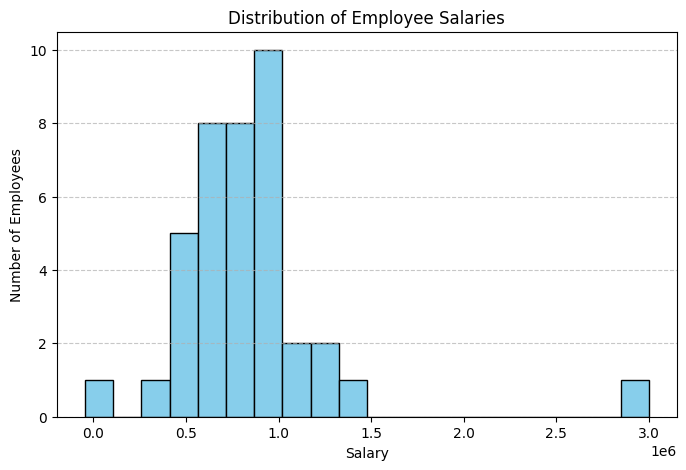

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Now your code will work perfectly:
plt.figure(figsize=(8, 5))
plt.hist(df["Salary"], bins=20, color="skyblue", edgecolor="black")
plt.title("Distribution of Employee Salaries")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13248\1178036831.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Department", y="Salary", data=sana, palette="Set2")


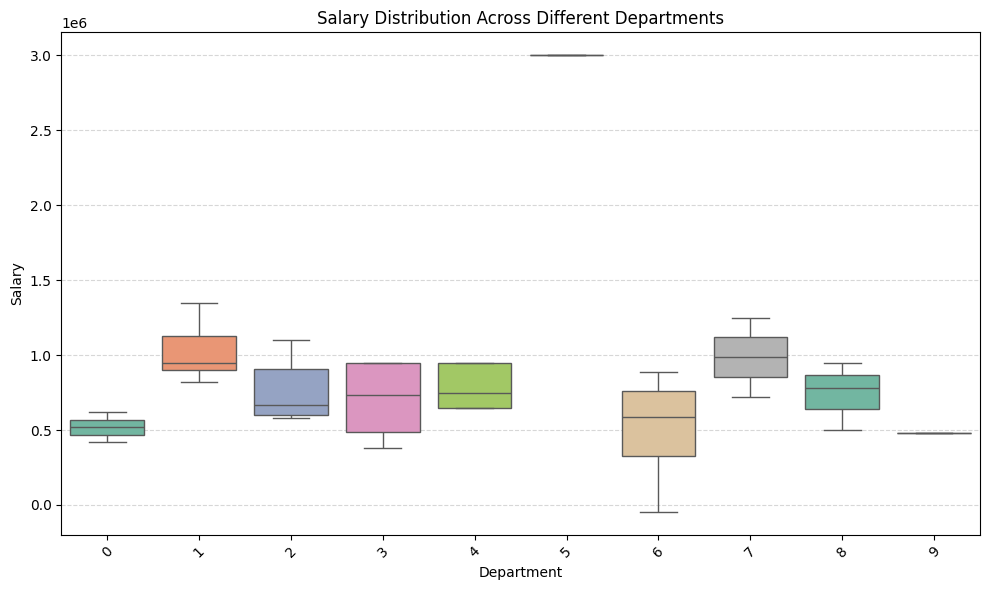

In [3]:
import seaborn as sns

# Box plot of Salary by Department
plt.figure(figsize=(10, 6))
sns.boxplot(x="Department", y="Salary", data=sana, palette="Set2")
plt.title("Salary Distribution Across Different Departments")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

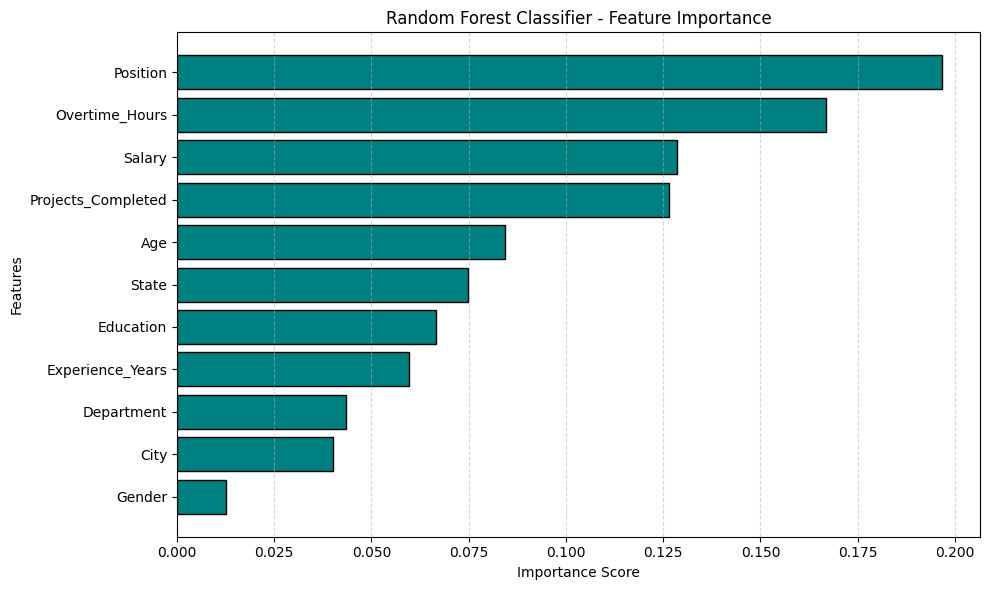

In [4]:
# Feature Importance Bar Plot
plt.figure(figsize=(10, 6))
plt.barh(importance["Feature"], importance["Importance"], color="teal", edgecolor="black")
plt.gca().invert_yaxis()  # Put the highest importance on top
plt.title("Random Forest Classifier - Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

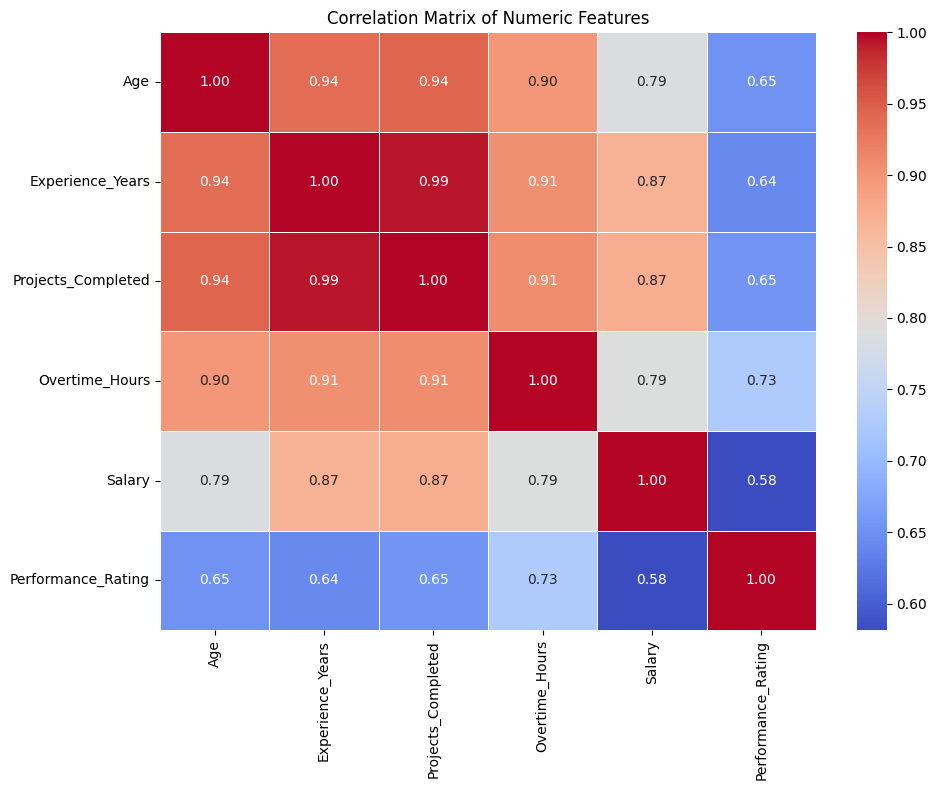

In [5]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df[["Age", "Experience_Years", "Projects_Completed", "Overtime_Hours", "Salary", "Performance_Rating"]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

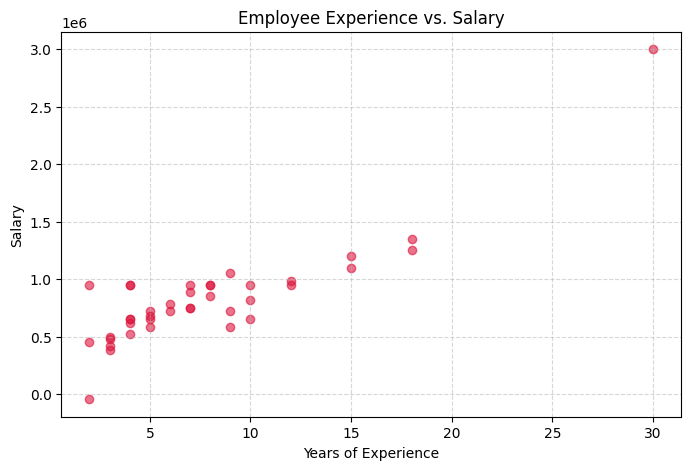

In [6]:
# Scatter Plot for Regression View
plt.figure(figsize=(8, 5))
plt.scatter(df["Experience_Years"], df["Salary"], alpha=0.6, color="crimson")
plt.title("Employee Experience vs. Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()